In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from datetime import datetime

In [7]:
ruta = Path("..") / "Data" / "dataset"

dataframes = {}

for archivo in ruta.glob("*.csv"):
    dataframes[archivo.stem] = pd.read_csv(archivo)

In [8]:
list(dataframes.keys())

['customers',
 'delivery_events',
 'drivers',
 'driver_monthly_metrics',
 'facilities',
 'fuel_purchases',
 'loads',
 'maintenance_records',
 'routes',
 'safety_incidents',
 'trailers',
 'trips',
 'trucks',
 'truck_utilization_metrics']

In [9]:
customers = dataframes['customers']
delivery_events = dataframes['delivery_events']
drivers = dataframes['drivers']
driver_monthly_metrics = dataframes['driver_monthly_metrics']
facilities = dataframes['facilities']
fuel_purchases = dataframes['fuel_purchases']
loads = dataframes['loads']
maintenance_records = dataframes['maintenance_records']
routes = dataframes['routes']
safety_incidents = dataframes['safety_incidents']
trailers = dataframes['trailers']
trips = dataframes['trips']
trucks = dataframes['trucks']
truck_utilization_metrics = dataframes['truck_utilization_metrics']

Durante la auditoría se han detectado que varias columnas que representan fechas y horas estaban almacenadas como object. Para facilitar el análisis temporal, el cálculo de intervalos de tiempo y el desarrollo de modelos predictivos, estas variables se convierten al tipo datetime.

In [10]:
delivery_events['scheduled_datetime'] = pd.to_datetime(delivery_events['scheduled_datetime'])
delivery_events['actual_datetime'] = pd.to_datetime(delivery_events['actual_datetime'])
driver_monthly_metrics['month'] = pd.to_datetime(driver_monthly_metrics['month'])
fuel_purchases['purchase_date'] = pd.to_datetime(fuel_purchases['purchase_date'])
loads['load_date'] = pd.to_datetime(loads['load_date'])
maintenance_records['maintenance_date'] = pd.to_datetime(maintenance_records['maintenance_date'])
safety_incidents['incident_date'] = pd.to_datetime(safety_incidents['incident_date'])
trailers['acquisition_date'] = pd.to_datetime(trailers['acquisition_date'])
trips['dispatch_date'] = pd.to_datetime(trips['dispatch_date'])
trucks['acquisition_date'] = pd.to_datetime(trucks['acquisition_date'])
truck_utilization_metrics['month'] = pd.to_datetime(truck_utilization_metrics['month'])

In [11]:
loads.head()

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,Completed,Spot
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,Completed,Dedicated
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,Completed,Spot
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,1308.20,141.33,50,Completed,Spot
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,3317.18,738.48,0,Completed,Spot


In [12]:
loads['load_status'].unique()

array(['Completed'], dtype=object)

*** Comportamiento de la actividad logística: números de cargas mensuales por año (analizo solo las cargas y no los viajes ya que la relación es 1:1 y así se evita duplicidad de indicadores). ***

In [13]:
loads_month_year = (
    loads
    .groupby([
        loads['load_date'].dt.year.rename('year'),
        loads['load_date'].dt.month.rename('month')
    ])
    .agg(num_loads=('load_id', 'count'))
    .reset_index()
)

loads_month_year.head()

,year,month,num_loads
0,2022,1,2466
1,2022,2,2179
2,2022,3,2370
3,2022,4,2346
4,2022,5,2428


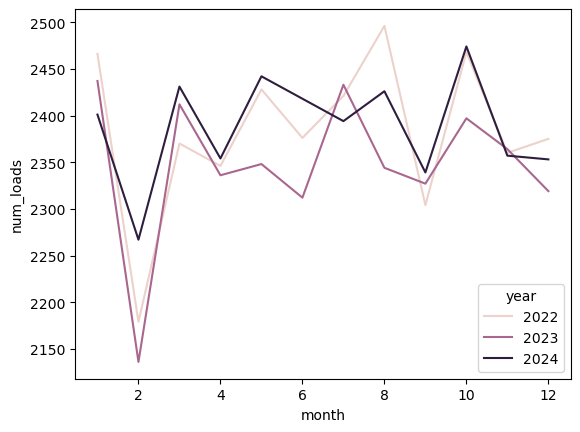

In [15]:
sns.lineplot(loads_month_year,
                x= 'month',
                y= 'num_loads',
                hue= 'year');            

In [17]:
loads_month_year['date'] = pd.to_datetime(loads_month_year[['year','month']].assign(day=1))    

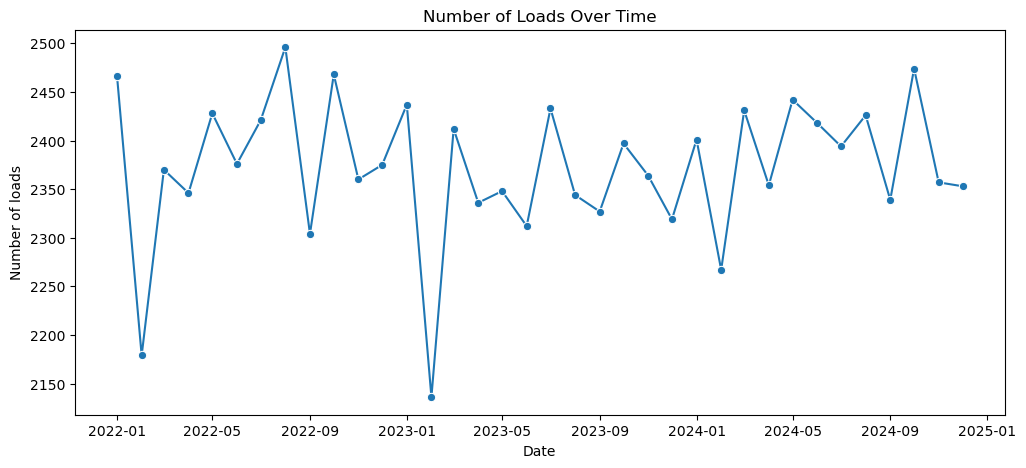

In [18]:
plt.figure(figsize=(12,5))

sns.lineplot(data=loads_month_year,
             x='date',
             y='num_loads',
             marker='o')

plt.title('Number of Loads Over Time')
plt.xlabel('Date')
plt.ylabel('Number of loads')

plt.show()

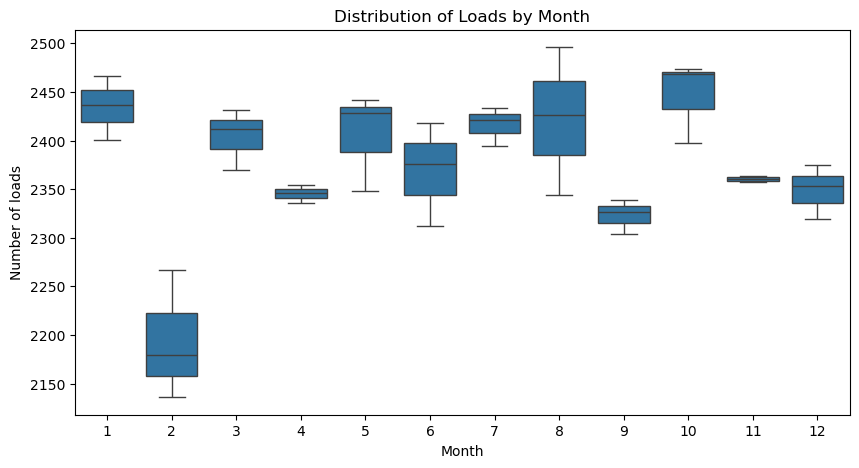

In [19]:
plt.figure(figsize=(10,5))

sns.boxplot(data=loads_month_year,
            x='month',
            y='num_loads')

plt.title('Distribution of Loads by Month')
plt.xlabel('Month')
plt.ylabel('Number of loads')

plt.show()

El volumen mensual de cargas presenta un comportamiento relativamente estable a lo largo del período analizado. Sin embargo, se observan descensos recurrentes de la actividad durante los meses de febrero y en menor medida en septiembre, lo que podría indicar la existencia de cierta estacionalidad en las operaciones logísticas. Asimismo, el año 2024 muestra una distribución más homogénea de la actividad entre los distintos meses, con menores variaciones respecto a los años anteriores.

*** Análisis general del comportamiento de los ingresos (Revenue) ***

In [20]:
revenue_month_year = (
    loads
    .groupby([
        loads['load_date'].dt.year.rename('year'),
        loads['load_date'].dt.month.rename('month')
    ])
    .agg(revenue=('revenue', 'sum'))
    .reset_index())

revenue_month_year.head()

,year,month,revenue
0,2022,1,7566361.99
1,2022,2,6574259.06
2,2022,3,7401197.05
3,2022,4,7156041.22
4,2022,5,7518061.33


In [21]:
fig = px.line(
    data_frame= revenue_month_year,
    x= "month",
    y= "revenue",
    color = 'year',
    markers= 'True')

fig.show()

Los ingresos muestran un comportamiento temporal semejante al número de cargas, teniendo al mes de Febrero con la disminución mas representativa coincidiendo con la disminución del número de cargas.

*** Análisis del comportamiento de los Costes (Combustible y Mantenimiento) ***

In [22]:
fuel_purchase_month_year = (
    fuel_purchases
    .groupby([
        fuel_purchases['purchase_date'].dt.year.rename('year'),
        fuel_purchases['purchase_date'].dt.month.rename('month')
    ])
    .agg(coste=('total_cost', 'sum'))
    .reset_index()
)

fuel_purchase_month_year.head()

,year,month,coste
0,2022,1,2822857.10
1,2022,2,2601024.90
2,2022,3,2855264.99
3,2022,4,2857719.10
4,2022,5,2881461.91


In [23]:
maintenance_records_month_year = (
    maintenance_records
    .groupby([
        maintenance_records['maintenance_date'].dt.year.rename('year'),
        maintenance_records['maintenance_date'].dt.month.rename('month')
    ])
    .agg(coste_sstt=('total_cost', 'sum'))
    .reset_index()
)

maintenance_records_month_year.head()

,year,month,coste_sstt
0,2022,1,173858.31
1,2022,2,128729.86
2,2022,3,150936.06
3,2022,4,205950.67
4,2022,5,155450.16


In [24]:
fig = px.line(
    data_frame= fuel_purchase_month_year,
    x= "month",
    y= "coste",
    color = 'year',
    markers= 'True')

fig.show()

In [25]:
fig = px.line(
    data_frame= maintenance_records_month_year,
    x= "month",
    y= "coste_sstt",
    color = 'year',
    markers= 'True')

fig.show()

- Durante 2022 se observa un mayor coste mensual asociado a las compras de combustible respecto a los años posteriores, los costes muestran un comportamiento más estable y con valores inferiores a los registrados en 2022.

- Los costes de mantenimiento presentan una mayor variabilidad mensual que el coste de combustible, sin apreciarse una tendencia creciente o decreciente claramente definida durante el periodo analizado. Se observan incrementos puntuales en determinados meses, que podrían estar asociados a operaciones extraordinarias de mantenimiento o al uso intensivo de la flota.


*** Eficiencia temporal de las operciones (Retraso medio por años en minutos)***

In [26]:
delivery_events.head()

,event_id,load_id,trip_id,event_type,facility_id,scheduled_datetime,actual_datetime,detention_minutes,on_time_flag,location_city,location_state
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,TX
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,MI
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,MO
3,EVT00000004,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,67,False,Indianapolis,IN
4,EVT00000005,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01 08:00:00.000000,2022-01-01 07:28:02.169634,83,True,Columbus,OH


In [27]:
delivery_events['scheduled_datetime'].dt.year.value_counts().sort_index()    # Se detectan valores correspondientes al 2025, los cuales constituten entregas o recogidas programadas de finales de 2024.

scheduled_datetime
2022    57084
2023    56344
2024    57315
2025       77
Name: count, dtype: int64

In [28]:
delivery_events['arrivel_delay_minutes'] = (delivery_events['actual_datetime'] - delivery_events['scheduled_datetime']).dt.total_seconds() / 60

delivery_delay = (
    delivery_events[
        delivery_events['scheduled_datetime'].dt.year <= 2024]
    .groupby(delivery_events['scheduled_datetime'].dt.year.rename('year'))
    .agg(avg_delay=('arrivel_delay_minutes', 'mean')).round(2)).reset_index()

delivery_delay

,year,avg_delay
0,2022,74.78
1,2023,75.38
2,2024,74.87


In [29]:
delivery_delay_type = (
    delivery_events[
        delivery_events['scheduled_datetime'].dt.year <= 2024]
    .groupby([delivery_events['scheduled_datetime'].dt.year.rename('year'), delivery_events['event_type']])
    .agg(avg_delay=('arrivel_delay_minutes', 'mean'))
    .round(2).reset_index())
    
delivery_delay_type

,year,event_type,avg_delay
0,2022,Delivery,90.33
1,2022,Pickup,59.29
2,2023,Delivery,90.94
3,2023,Pickup,59.81
4,2024,Delivery,89.70
5,2024,Pickup,60.04


In [30]:
delivery_events_box = delivery_events[
    delivery_events['scheduled_datetime'].dt.year <= 2024].copy()

delivery_events_box['year'] = (delivery_events_box['scheduled_datetime']
    .dt.year
    .astype(str))

fig = px.box(
    delivery_events_box,
    x='event_type',
    y='arrivel_delay_minutes',
    facet_col='year',
    color='event_type',
    points=False,
    template='plotly_white'
)

fig.update_layout(
    title='Distribution of operational delays by event type',
    title_x=0.5
)

fig.show()

El retraso medio de las operaciones se mantiene prácticamente constante durante el periodo 2022–2024, situándose en torno a los 75 minutos, mostrando que la mayor fase de las desviaciones se produce en las operaciones de Delivery presentan un retraso medio cercano a 90 minutos, mientras que las operaciones de Pickup se sitúan alrededor de 60 minutos.